SIMULADOR DE CADENAS DE MARKOV
Versión sin dependencias externas

Requisitos mínimos: numpy, matplotlib, scipy
✓ Dependencias encontradas

SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente)
4. Crear mi propia cadena
5. Salir

EJEMPLO 1: CADENA DE MARKOV SIMPLE (3 ESTADOS)
ANÁLISIS DE CADENA DE MARKOV

1. INFORMACIÓN BÁSICA:
   Número de estados: 3
   Estados: ['Soleado', 'Nublado', 'Lluvioso']

2. MATRIZ DE TRANSICIÓN:
   Soleado: [0.700, 0.200, 0.100]
   Nublado: [0.300, 0.500, 0.200]
   Lluvioso: [0.200, 0.300, 0.500]

3. DISTRIBUCIÓN ESTACIONARIA:
   Soleado: 0.4634 (46.3%)
   Nublado: 0.3171 (31.7%)
   Lluvioso: 0.2195 (22.0%)

4. TIEMPOS MEDIOS DE RETORNO:
   Soleado: 2.16 pasos
   Nublado: 3.15 pasos
   Lluvioso: 4.56 pasos

5. DISTRIBUCIÓN DESPUÉS DE 5 DÍAS (comienza nublado):
   Soleado: 0.4583
   Nublado: 0.3194
   Lluvioso: 0.2223

6. GENERANDO GRÁFICOS...


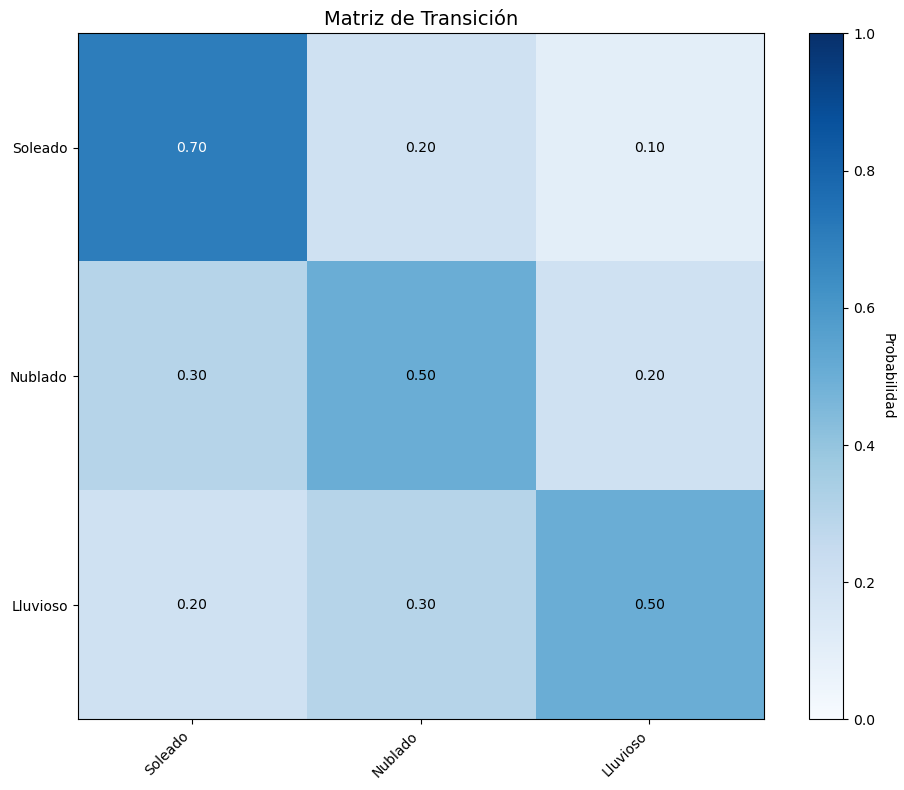

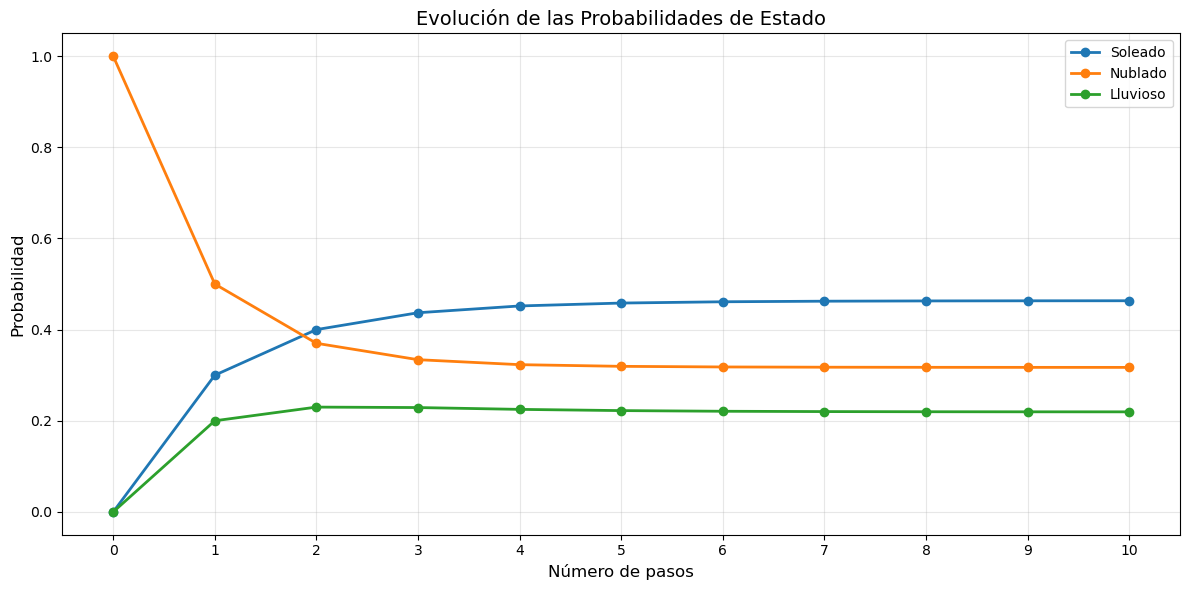


SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente)
4. Crear mi propia cadena
5. Salir

EJEMPLO 2: CADENA CON ESTADO ABSORBENTE

Distribuciones a lo largo del tiempo:
  Año 1: Estudiante=0.7000, Graduado=0.3000
  Año 2: Estudiante=0.4900, Graduado=0.5100
  Año 5: Estudiante=0.1681, Graduado=0.8319
  Año 10: Estudiante=0.0282, Graduado=0.9718
  Año 20: Estudiante=0.0008, Graduado=0.9992

Distribución estacionaria:
  Estudiante: 0.0000
  Graduado: 1.0000

Tiempo medio hasta graduación: 3.33 años


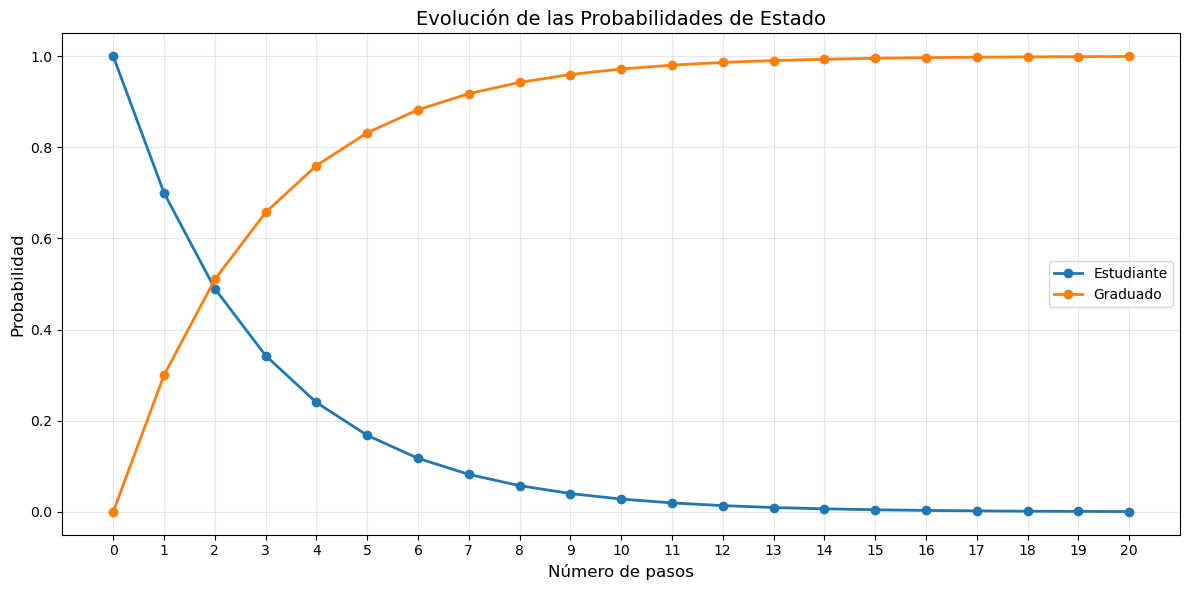


SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente)
4. Crear mi propia cadena
5. Salir

EJEMPLO 3: CADENA COMPLEJA (4 ESTADOS) - Comportamiento cliente
ANÁLISIS DE CADENA DE MARKOV

1. INFORMACIÓN BÁSICA:
   Número de estados: 4
   Estados: ['Nuevo', 'Activo', 'Inactivo', 'Perdido']

2. MATRIZ DE TRANSICIÓN:
   Nuevo: [0.100, 0.600, 0.200, 0.100]
   Activo: [0.000, 0.700, 0.200, 0.100]
   Inactivo: [0.100, 0.300, 0.500, 0.100]
   Perdido: [0.000, 0.000, 0.000, 1.000]

3. DISTRIBUCIÓN ESTACIONARIA:
   Nuevo: 0.0000 (0.0%)
   Activo: 0.0000 (0.0%)
   Inactivo: 0.0000 (0.0%)
   Perdido: 1.0000 (100.0%)

4. TIEMPOS MEDIOS DE RETORNO:
   Nuevo: inf pasos
   Activo: inf pasos
   Inactivo: inf pasos
   Perdido: 1.00 pasos

Simulación de trayectoria (20 meses):
  Trayectoria: Nuevo → Activo → Activo → Activo → Activo → Activo → Inactivo → Inactivo → Activo → Activo → Inactivo → Nuevo → 

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_4188\2458178796.py:139: RuntimeWarning: divide by zero encountered in divide
  tiempos = 1 / pi_estable


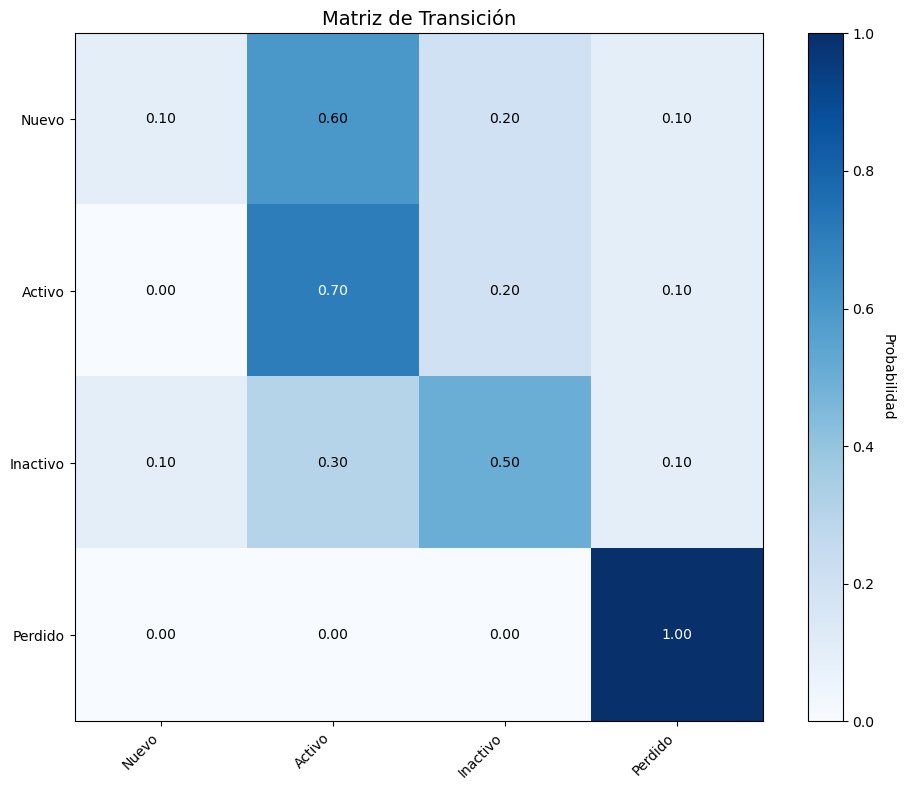

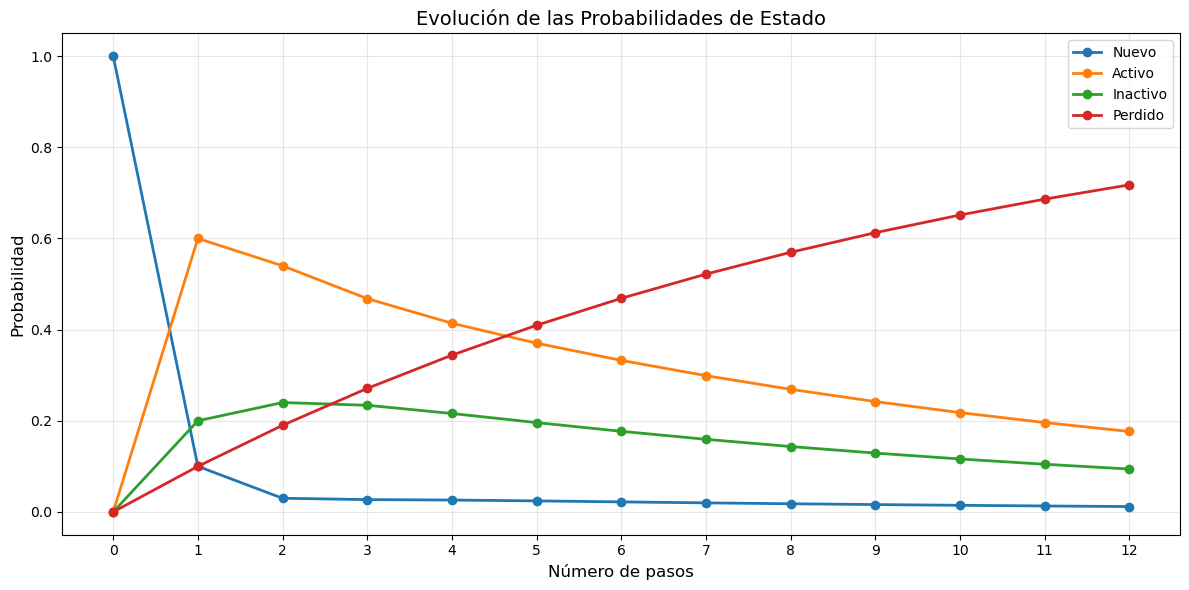


SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente)
4. Crear mi propia cadena
5. Salir

¡Hasta luego!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

class CadenaMarkov:
    def __init__(self, matriz_transicion, estados=None):
        """
        Inicializa una cadena de Markov
        
        Args:
            matriz_transicion: Matriz de transición (n x n)
            estados: Nombres de los estados (opcional)
        """
        self.P = np.array(matriz_transicion, dtype=float)
        self.n_estados = self.P.shape[0]
        
        # Verificar que es matriz de transición válida
        self._verificar_matriz()
        
        # Nombres de estados
        if estados is None:
            self.estados = [f"E{i+1}" for i in range(self.n_estados)]
        else:
            self.estados = estados
    
    def _verificar_matriz(self):
        """Verifica que la matriz sea estocástica"""
        # Verificar dimensiones
        if self.P.shape[0] != self.P.shape[1]:
            raise ValueError("La matriz debe ser cuadrada")
        
        # Verificar que las filas sumen 1
        suma_filas = np.sum(self.P, axis=1)
        if not np.allclose(suma_filas, 1.0):
            print(f"Suma de filas: {suma_filas}")
            print("Normalizando filas...")
            # Normalizar cada fila
            for i in range(self.n_estados):
                suma = np.sum(self.P[i])
                if suma > 0:
                    self.P[i] = self.P[i] / suma
                else:
                    self.P[i] = np.ones(self.n_estados) / self.n_estados
        
        # Verificar que todos los valores estén entre 0 y 1
        if np.any(self.P < 0):
            print("¡ADVERTENCIA! Hay probabilidades negativas. Ajustando...")
            self.P = np.maximum(self.P, 0)
            self.P = self.P / np.sum(self.P, axis=1, keepdims=True)
    
    def distribucion_n_pasos(self, pi0, n):
        """
        Calcula la distribución después de n pasos
        
        Args:
            pi0: Vector de distribución inicial
            n: Número de pasos
            
        Returns:
            Vector de distribución después de n pasos
        """
        pi0 = np.array(pi0, dtype=float)
        
        # Normalizar pi0 si es necesario
        suma_pi0 = np.sum(pi0)
        if not np.isclose(suma_pi0, 1.0):
            print(f"Distribución inicial no suma 1 ({suma_pi0:.4f}). Normalizando...")
            pi0 = pi0 / suma_pi0
        
        # Calcular P^n
        P_n = np.linalg.matrix_power(self.P, n)
        
        # Distribución después de n pasos
        pi_n = pi0 @ P_n
        
        return pi_n
    
    def estado_estable(self, metodo='autovector', max_iter=1000, tol=1e-10):
        """
        Calcula la distribución estacionaria/estable
        
        Args:
            metodo: 'autovector' o 'iterativo'
            max_iter: Máximo de iteraciones para método iterativo
            tol: Tolerancia para convergencia
            
        Returns:
            Distribución estacionaria
        """
        if metodo == 'autovector':
            # Método 1: Autovector izquierdo con autovalor 1
            # Encontrar autovectores de P^T
            valores, vectores = np.linalg.eig(self.P.T)
            
            # Encontrar índice del autovalor 1 (o más cercano a 1)
            idx = np.argmin(np.abs(valores - 1.0))
            
            # Obtener el autovector correspondiente
            pi_estable = np.real(vectores[:, idx])
            
            # Asegurar que todos sean positivos
            pi_estable = np.abs(pi_estable)
            
            # Normalizar para que sume 1
            pi_estable = pi_estable / np.sum(pi_estable)
            
        elif metodo == 'iterativo':
            # Método 2: Iteración hasta convergencia
            pi = np.ones(self.n_estados) / self.n_estados  # Distribución inicial uniforme
            
            for i in range(max_iter):
                pi_nuevo = pi @ self.P
                
                # Verificar convergencia
                if np.linalg.norm(pi_nuevo - pi) < tol:
                    print(f"Convergencia alcanzada en {i+1} iteraciones")
                    pi = pi_nuevo
                    break
                
                pi = pi_nuevo
                
                if i == max_iter - 1:
                    print(f"Advertencia: No convergió en {max_iter} iteraciones")
            
            pi_estable = pi
        else:
            raise ValueError("Método debe ser 'autovector' o 'iterativo'")
        
        return pi_estable
    
    def tiempo_medio_retorno(self):
        """
        Calcula tiempos medios de retorno a cada estado
        
        Returns:
            Array con tiempos medios de retorno
        """
        pi_estable = self.estado_estable()
        tiempos = 1 / pi_estable
        return tiempos
    
    def analizar_cadena(self):
        """Realiza análisis completo de la cadena"""
        print("=" * 60)
        print("ANÁLISIS DE CADENA DE MARKOV")
        print("=" * 60)
        
        # 1. Información básica
        print(f"\n1. INFORMACIÓN BÁSICA:")
        print(f"   Número de estados: {self.n_estados}")
        print(f"   Estados: {self.estados}")
        
        # 2. Matriz de transición
        print(f"\n2. MATRIZ DE TRANSICIÓN:")
        for i, fila in enumerate(self.P):
            print(f"   {self.estados[i]}: [{', '.join([f'{p:.3f}' for p in fila])}]")
        
        # 3. Distribución estacionaria
        print(f"\n3. DISTRIBUCIÓN ESTACIONARIA:")
        pi_estable = self.estado_estable()
        for i, prob in enumerate(pi_estable):
            print(f"   {self.estados[i]}: {prob:.4f} ({prob*100:.1f}%)")
        
        # 4. Tiempos medios de retorno
        tiempos = self.tiempo_medio_retorno()
        print(f"\n4. TIEMPOS MEDIOS DE RETORNO:")
        for i, t in enumerate(tiempos):
            print(f"   {self.estados[i]}: {t:.2f} pasos")
        
        print("=" * 60)
        
        return {
            'estacionaria': pi_estable,
            'tiempos_retorno': tiempos
        }
    
    def simular(self, pi0, pasos=20):
        """
        Simula una trayectoria de la cadena
        
        Args:
            pi0: Distribución inicial
            pasos: Número de pasos a simular
            
        Returns:
            Lista con la secuencia de estados
        """
        # Normalizar pi0
        pi0 = np.array(pi0, dtype=float)
        suma_pi0 = np.sum(pi0)
        if not np.isclose(suma_pi0, 1.0):
            pi0 = pi0 / suma_pi0
        
        # Estado inicial
        estado_actual = np.random.choice(self.n_estados, p=pi0)
        trayectoria = [estado_actual]
        
        # Simular pasos siguientes
        for _ in range(pasos - 1):
            # Elegir próximo estado según distribución de la fila actual
            proximo_estado = np.random.choice(
                self.n_estados, 
                p=self.P[estado_actual]
            )
            trayectoria.append(proximo_estado)
            estado_actual = proximo_estado
        
        return trayectoria
    
    def graficar_evolucion(self, pi0, max_pasos=10):
        """
        Grafica la evolución de las probabilidades
        
        Args:
            pi0: Distribución inicial
            max_pasos: Número máximo de pasos a graficar
        """
        # Calcular distribuciones para cada paso
        distribuciones = []
        pi_actual = np.array(pi0, dtype=float)
        suma_pi_actual = np.sum(pi_actual)
        if not np.isclose(suma_pi_actual, 1.0):
            pi_actual = pi_actual / suma_pi_actual
        
        distribuciones.append(pi_actual)
        
        for paso in range(1, max_pasos + 1):
            pi_actual = pi_actual @ self.P
            distribuciones.append(pi_actual)
        
        distribuciones = np.array(distribuciones)
        
        # Crear gráfico
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for i in range(self.n_estados):
            ax.plot(range(max_pasos + 1), 
                   distribuciones[:, i], 
                   marker='o', 
                   label=self.estados[i], 
                   linewidth=2)
        
        ax.set_xlabel('Número de pasos', fontsize=12)
        ax.set_ylabel('Probabilidad', fontsize=12)
        ax.set_title('Evolución de las Probabilidades de Estado', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xticks(range(max_pasos + 1))
        
        plt.tight_layout()
        return fig, ax
    
    def graficar_matriz(self):
        """Grafica la matriz de transición como heatmap"""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Crear heatmap
        im = ax.imshow(self.P, cmap='Blues', vmin=0, vmax=1)
        
        # Añadir texto en cada celda
        for i in range(self.n_estados):
            for j in range(self.n_estados):
                ax.text(j, i, f'{self.P[i, j]:.2f}',
                       ha='center', va='center',
                       color='black' if self.P[i, j] < 0.7 else 'white')
        
        # Configurar ejes
        ax.set_xticks(range(self.n_estados))
        ax.set_yticks(range(self.n_estados))
        ax.set_xticklabels(self.estados)
        ax.set_yticklabels(self.estados)
        
        # Rotar etiquetas del eje x
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Añadir barra de color
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel('Probabilidad', rotation=-90, va='bottom')
        
        ax.set_title('Matriz de Transición', fontsize=14)
        plt.tight_layout()
        
        return fig, ax


# ============================================================================
# EJEMPLOS DE USO
# ============================================================================

def ejemplo_simple():
    """Ejemplo 1: Cadena de Markov simple de 3 estados"""
    print("\n" + "="*60)
    print("EJEMPLO 1: CADENA DE MARKOV SIMPLE (3 ESTADOS)")
    print("="*60)
    
    # Definir matriz de transición (ejemplo: clima)
    P = [
        [0.7, 0.2, 0.1],  # Soleado → Soleado, Nublado, Lluvioso
        [0.3, 0.5, 0.2],  # Nublado → Soleado, Nublado, Lluvioso
        [0.2, 0.3, 0.5]   # Lluvioso → Soleado, Nublado, Lluvioso
    ]
    
    estados = ["Soleado", "Nublado", "Lluvioso"]
    
    # Crear cadena de Markov
    cadena = CadenaMarkov(P, estados)
    
    # Analizar completamente
    resultados = cadena.analizar_cadena()
    
    # Calcular distribuciones específicas
    pi0 = [0, 1, 0]  # Comienza nublado
    
    print("\n5. DISTRIBUCIÓN DESPUÉS DE 5 DÍAS (comienza nublado):")
    pi5 = cadena.distribucion_n_pasos(pi0, 5)
    for i, (estado, prob) in enumerate(zip(estados, pi5)):
        print(f"   {estado}: {prob:.4f}")
    
    # Graficar
    print("\n6. GENERANDO GRÁFICOS...")
    fig1, ax1 = cadena.graficar_matriz()
    fig2, ax2 = cadena.graficar_evolucion(pi0, max_pasos=10)
    
    plt.show()
    
    return cadena, resultados

def ejemplo_absorbente():
    """Ejemplo 2: Cadena con estado absorbente"""
    print("\n" + "="*60)
    print("EJEMPLO 2: CADENA CON ESTADO ABSORBENTE")
    print("="*60)
    
    # Estados: 0=Estudiante, 1=Graduado (absorbente)
    P = [
        [0.7, 0.3],  # Estudiante → Estudiante, Graduado
        [0.0, 1.0]   # Graduado → Graduado, Graduado
    ]
    
    estados = ["Estudiante", "Graduado"]
    
    cadena = CadenaMarkov(P, estados)
    
    # Distribución inicial: 100% estudiante
    pi0 = [1, 0]
    
    print("\nDistribuciones a lo largo del tiempo:")
    for n in [1, 2, 5, 10, 20]:
        pi_n = cadena.distribucion_n_pasos(pi0, n)
        print(f"  Año {n}: Estudiante={pi_n[0]:.4f}, Graduado={pi_n[1]:.4f}")
    
    print("\nDistribución estacionaria:")
    pi_estable = cadena.estado_estable()
    for i, (estado, prob) in enumerate(zip(estados, pi_estable)):
        print(f"  {estado}: {prob:.4f}")
    
    # Tiempo medio hasta graduación
    print(f"\nTiempo medio hasta graduación: {1/P[0][1]:.2f} años")
    
    # Graficar evolución
    fig, ax = cadena.graficar_evolucion(pi0, max_pasos=20)
    plt.show()
    
    return cadena

def ejemplo_complejo():
    """Ejemplo 3: Cadena más compleja (4 estados)"""
    print("\n" + "="*60)
    print("EJEMPLO 3: CADENA COMPLEJA (4 ESTADOS) - Comportamiento cliente")
    print("="*60)
    
    # Estados de un cliente: 0=Nuevo, 1=Activo, 2=Inactivo, 3=Perdido
    P = [
        [0.1, 0.6, 0.2, 0.1],  # Nuevo
        [0.0, 0.7, 0.2, 0.1],  # Activo
        [0.1, 0.3, 0.5, 0.1],  # Inactivo
        [0.0, 0.0, 0.0, 1.0]   # Perdido (absorbente)
    ]
    
    estados = ["Nuevo", "Activo", "Inactivo", "Perdido"]
    
    cadena = CadenaMarkov(P, estados)
    
    # Análisis completo
    resultados = cadena.analizar_cadena()
    
    # Simulación
    print("\nSimulación de trayectoria (20 meses):")
    pi0 = [1, 0, 0, 0]  # Cliente nuevo
    trayectoria = cadena.simular(pi0, pasos=20)
    
    # Convertir índices a nombres de estados
    trayectoria_nombres = [estados[i] for i in trayectoria]
    print("  Trayectoria:", " → ".join(trayectoria_nombres))
    
    # Gráficos
    print("\nGenerando gráficos...")
    fig1, ax1 = cadena.graficar_matriz()
    fig2, ax2 = cadena.graficar_evolucion(pi0, max_pasos=12)
    
    plt.show()
    
    return cadena

def interfaz_interactiva():
    """Interfaz interactiva en consola"""
    while True:
        print("\n" + "="*60)
        print("SIMULADOR DE CADENAS DE MARKOV")
        print("="*60)
        print("1. Ejemplo simple (clima - 3 estados)")
        print("2. Ejemplo con estado absorbente (graduación)")
        print("3. Ejemplo complejo (comportamiento cliente)")
        print("4. Crear mi propia cadena")
        print("5. Salir")
        print("="*60)
        
        opcion = input("\nSelecciona una opción (1-5): ").strip()
        
        if opcion == '1':
            ejemplo_simple()
            
        elif opcion == '2':
            ejemplo_absorbente()
            
        elif opcion == '3':
            ejemplo_complejo()
            
        elif opcion == '4':
            crear_cadena_personalizada()
            
        elif opcion == '5':
            print("\n¡Hasta luego!")
            break
            
        else:
            print("\nOpción no válida. Intenta de nuevo.")

def crear_cadena_personalizada():
    """Permite al usuario crear su propia cadena"""
    print("\n" + "="*60)
    print("CREAR CADENA PERSONALIZADA")
    print("="*60)
    
    try:
        # Solicitar número de estados
        n = int(input("¿Cuántos estados tiene tu cadena? (2-10): "))
        if n < 2 or n > 10:
            print("El número de estados debe estar entre 2 y 10")
            return
        
        # Solicitar nombres de estados
        estados = []
        for i in range(n):
            nombre = input(f"Nombre del estado {i+1}: ").strip()
            if not nombre:
                nombre = f"E{i+1}"
            estados.append(nombre)
        
        # Solicitar matriz de transición
        print(f"\nIngresa la matriz de transición {n}x{n} (filas deben sumar aproximadamente 1):")
        P = []
        
        for i in range(n):
            print(f"\nProbabilidades desde estado '{estados[i]}':")
            fila = []
            suma_fila = 0
            
            for j in range(n):
                while True:
                    try:
                        prompt = f"  Probabilidad de ir a '{estados[j]}': "
                        prob = float(input(prompt))
                        if prob < 0 or prob > 1:
                            print("    La probabilidad debe estar entre 0 y 1")
                            continue
                        fila.append(prob)
                        suma_fila += prob
                        break
                    except ValueError:
                        print("    Ingresa un número válido")
            
            print(f"  Suma de la fila: {suma_fila:.4f}")
            if not np.isclose(suma_fila, 1.0, atol=0.1):
                print("  ¡ADVERTENCIA! La fila no suma 1. Se normalizará automáticamente.")
            
            P.append(fila)
        
        # Distribución inicial
        print(f"\nDistribución inicial:")
        pi0 = []
        suma_pi0 = 0
        
        for i, estado in enumerate(estados):
            while True:
                try:
                    prompt = f"  Probabilidad inicial para '{estado}': "
                    prob = float(input(prompt))
                    if prob < 0 or prob > 1:
                        print("    La probabilidad debe estar entre 0 y 1")
                        continue
                    pi0.append(prob)
                    suma_pi0 += prob
                    break
                except ValueError:
                    print("    Ingresa un número válido")
        
        print(f"  Suma de distribución inicial: {suma_pi0:.4f}")
        
        # Crear cadena
        nombre = input("\nNombre para esta cadena: ").strip()
        if not nombre:
            nombre = "Mi Cadena Personalizada"
        
        cadena = CadenaMarkov(P, estados)
        
        # Mostrar resultados
        print(f"\n{'='*60}")
        print(f"CADENA '{nombre}' CREADA EXITOSAMENTE")
        print(f"{'='*60}")
        
        # Análisis
        resultados = cadena.analizar_cadena()
        
        # Calcular para pasos específicos
        try:
            n_pasos = int(input("\n¿Para cuántos pasos quieres calcular la distribución? "))
            pi_n = cadena.distribucion_n_pasos(pi0, n_pasos)
            
            print(f"\nDistribución después de {n_pasos} pasos:")
            for estado, prob in zip(estados, pi_n):
                print(f"  {estado}: {prob:.4f} ({prob*100:.1f}%)")
        except ValueError:
            print("Número de pasos no válido")
        
        # Graficar
        graficar = input("\n¿Quieres ver gráficos? (s/n): ").strip().lower()
        if graficar == 's':
            fig1, ax1 = cadena.graficar_matriz()
            fig2, ax2 = cadena.graficar_evolucion(pi0, max_pasos=10)
            plt.show()
        
        return cadena
        
    except KeyboardInterrupt:
        print("\n\nOperación cancelada por el usuario")
        return None
    except Exception as e:
        print(f"\nError: {e}")
        return None


# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    print("SIMULADOR DE CADENAS DE MARKOV")
    print("Versión sin dependencias externas")
    print("\nRequisitos mínimos: numpy, matplotlib, scipy")
    
    # Verificar dependencias
    try:
        import numpy as np
        import matplotlib.pyplot as plt
        print("✓ Dependencias encontradas")
    except ImportError as e:
        print(f"\n✗ Error: {e}")
        print("\nInstala las dependencias con:")
        print("pip install numpy matplotlib scipy")
        exit(1)
    
    # Ejecutar interfaz interactiva
    interfaz_interactiva()

In [3]:
import numpy as np

class MarkovSimple:
    def __init__(self, P, estados=None):
        """Versión mínima de cadena de Markov"""
        self.P = np.array(P)
        self.n = len(P)
        self.estados = estados or [f"S{i}" for i in range(self.n)]
    
    def distribucion_estacionaria(self):
        """Calcula distribución estacionaria"""
        # Encontrar autovector de P^T con autovalor 1
        valores, vectores = np.linalg.eig(self.P.T)
        idx = np.argmin(np.abs(valores - 1.0))
        pi = np.real(vectores[:, idx])
        return pi / pi.sum()
    
    def n_pasos(self, pi0, n):
        """Distribución después de n pasos"""
        P_n = np.linalg.matrix_power(self.P, n)
        return pi0 @ P_n

# Ejemplo de uso mínimo
if __name__ == "__main__":
    # Matriz de transición 2x2
    P = [[0.9, 0.1], [0.5, 0.5]]
    
    # Crear cadena
    mc = MarkovSimple(P, estados=["A", "B"])
    
    # Calcular distribución estacionaria
    pi_estable = mc.distribucion_estacionaria()
    print("Distribución estacionaria:", pi_estable)
    
    # Calcular después de 10 pasos (comienza en estado A)
    pi0 = [1, 0]
    pi10 = mc.n_pasos(pi0, 10)
    print("Después de 10 pasos:", pi10)

Distribución estacionaria: [0.83333333 0.16666667]
Después de 10 pasos: [0.83335081 0.16664919]
